In [1]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 81.8 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12

In [2]:
!pip install -q --upgrade accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 6.6 MB/s eta 0:00:00a 0:00:01


In [ ]:
import datetime
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torch.nn.functional as F
import tqdm

from accelerate import Accelerator, notebook_launcher
from matplotlib.colors import ListedColormap
from torch.utils.data import DataLoader, Dataset
from torchmetrics.classification import MulticlassF1Score, MulticlassJaccardIndex
from torchvision import tv_tensors
from torchvision.models import ResNet34_Weights, resnet34
from torchvision.transforms import v2

from src.datasets import CloudDataset
from src.models import UNetPlusPlusResNet34, CosineAnnealingWarmRestartsDecay


warnings.filterwarnings("ignore")

In [ ]:
DATA = "../input/datasets/toasunzce/cloud-segmentation/data"
EPOCHS = 20
BATCH = 16   # effective batch = 16 * 2 = 32

subdir = datetime.datetime.now().strftime("%d_%m_%Y-%H_%M")
WEIGHTS_DIR = "/kaggle/working/cloud_weights/" + subdir
os.makedirs(WEIGHTS_DIR, exist_ok=True)

CLASS_NAMES = ["clear", "thick", "thin", "shadow"]
CMAP = ListedColormap(["black", "red", "orange", "gray"])

In [6]:
def plot_history(hist, epoch):
    
    epochs = range(1, len(hist["loss"]) + 1)
    
    iou = np.array(hist["iou"])
    dice = np.array(hist["dice"])
    losses = np.array(hist["loss"])
    lrs = np.array(hist["lr"])

    # figure setup
    fig = plt.figure(figsize=(8, 12), layout="constrained")
    spec = fig.add_gridspec(4, 3)

    ax0a = fig.add_subplot(spec[0, :2])
    ax0b = fig.add_subplot(spec[0, 2])

    ax1a = fig.add_subplot(spec[1, :2])
    ax1b = fig.add_subplot(spec[1, 2])

    ax2 = fig.add_subplot(spec[2, :])
    ax3 = fig.add_subplot(spec[3, :])

    # iou
    ax0a.plot(epochs, iou.mean(axis=1), "k--", label="mIoU")
    ax0a.set_title("val IoU per class")
    ax0a.set_xlabel("epoch")
    ax0a.set_ylim(0, 1)
    ax0a.grid(True)

    ax0b.plot(epochs[-5:], iou.mean(axis=1)[-5:], "k--")
    ax0b.set_title("TRUNC val IoU per class")
    ax0b.set_xlabel("epoch")
    ax0b.set_ylim(0, 1)
    ax0b.grid(True)
    if len(epochs) >= 3:
        ax0b.axvline(x=epochs[-3], color='red', linestyle='dotted')

    for c, name in enumerate(CLASS_NAMES):
        ax0a.plot(epochs, iou[:, c], label=name)
        ax0b.plot(epochs[-5:], iou[:, c][-5:])
    
    ax0a.legend(loc="lower right")
    
    # dice
    ax1a.plot(epochs, dice.mean(axis=1), "k--", label="mDice")
    ax1a.set_title("val Dice per class")
    ax1a.set_xlabel("epoch")
    ax1a.set_ylim(0, 1)
    ax1a.grid(True)

    ax1b.plot(epochs[-5:], dice.mean(axis=1)[-5:], "k--")
    ax1b.set_title("TRUNC val Dice per class")
    ax1b.set_xlabel("epoch")
    ax1b.set_ylim(0, 1)
    ax1b.grid(True)
    if len(epochs) >= 3:
        ax1b.axvline(x=epochs[-3], color='red', linestyle='dotted')

    for c, name in enumerate(CLASS_NAMES):
        ax1a.plot(epochs, dice[:, c], label=name)
        ax1b.plot(epochs[-5:], dice[:, c][-5:])
    
    ax1a.legend(loc="lower right")
        
    # loss
    ax2.plot(epochs, losses, color="tab:blue")
    ax2.set_title("train loss")
    ax2.set_xlabel("epoch")
    ax2.grid(True)

    # lr
    ax3.plot(epochs, lrs, color="tab:red")
    ax3.set_title("learning_rate")
    ax3.set_xlabel("epoch")
    ax3.grid(True)
    
    plt.savefig(os.path.join(WEIGHTS_DIR, "convergence.png"))
    plt.show()

In [ ]:
def train_fn():
    accelerator = Accelerator(mixed_precision="fp16")

    train_ds = CloudDataset(DATA, "train")
    valid_ds = CloudDataset(DATA, "val")
    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(valid_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

    with accelerator.main_process_first():
        model = UNetPlusPlusResNet34(pretrained="imagenet")

    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
    scheduler = CosineAnnealingWarmRestartsDecay(
        optimizer, T_0=10, T_mult=1, eta_min=3e-5, decay=0.5
    )

    w = torch.tensor([0.279, 0.541, 1.556, 1.633], device=accelerator.device)
    ce = nn.CrossEntropyLoss(weight=w)
    lovasz = smp.losses.LovaszLoss(mode="multiclass", per_image=False)

    iou_metric  = MulticlassJaccardIndex(num_classes=4, average=None).to(accelerator.device)
    dice_metric = MulticlassF1Score(num_classes=4, average=None).to(accelerator.device)

    model, optimizer, train_loader, val_loader = accelerator.prepare(
        model, optimizer, train_loader, val_loader
    )

    hist = {"loss": [], "iou": [], "dice": [], "lr": []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running = 0.0
        for x, y in tqdm.tqdm(train_loader, disable=not accelerator.is_local_main_process):
            optimizer.zero_grad()
            logits = model(x)
            loss = ce(logits, y) + 0.5 * lovasz(logits, y)
            accelerator.backward(loss)
            optimizer.step()
            running += loss.item()
        train_loss = running / len(train_loader)

        model.eval()
        iou_metric.reset(); dice_metric.reset()
        with torch.no_grad():
            for x, y in val_loader:
                preds = model(x).argmax(dim=1)
                preds, y = accelerator.gather_for_metrics((preds, y))
                iou_metric.update(preds, y)
                dice_metric.update(preds, y)
        iou = iou_metric.compute()
        dsc = dice_metric.compute()
        miou, mdice = iou.mean().item(), dsc.mean().item()

        scheduler.step()

        if accelerator.is_main_process:
            print(f"epoch {epoch}: loss={train_loss:.3f}  mIoU={miou:.3f}  mDice={mdice:.3f}")
            for c, name in enumerate(CLASS_NAMES):
                print(f"  {name:7s} IoU={iou[c]:.3f}  Dice={dsc[c]:.3f}")
            print(f"lr: {optimizer.param_groups[0]['lr']}")
            hist["loss"].append(train_loss)
            hist["iou"].append(iou.tolist())
            hist["dice"].append(dsc.tolist())
            hist["lr"].append(optimizer.param_groups[0]['lr'])
            unwrapped_model = accelerator.unwrap_model(model)
            accelerator.save(unwrapped_model.state_dict(),
                              os.path.join(WEIGHTS_DIR, f"epoch_{epoch:02d}.pt"))
            plot_history(hist, epoch)

Launching training on 2 CUDAs.


model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

100%|██████████| 249/249 [06:47<00:00,  1.64s/it]


epoch 1: loss=1.004  mIoU=0.613  mDice=0.750
  clear   IoU=0.806  Dice=0.892
  thick   IoU=0.709  Dice=0.830
  thin    IoU=0.471  Dice=0.640
  shadow  IoU=0.468  Dice=0.637
lr: 0.0002933926296998457


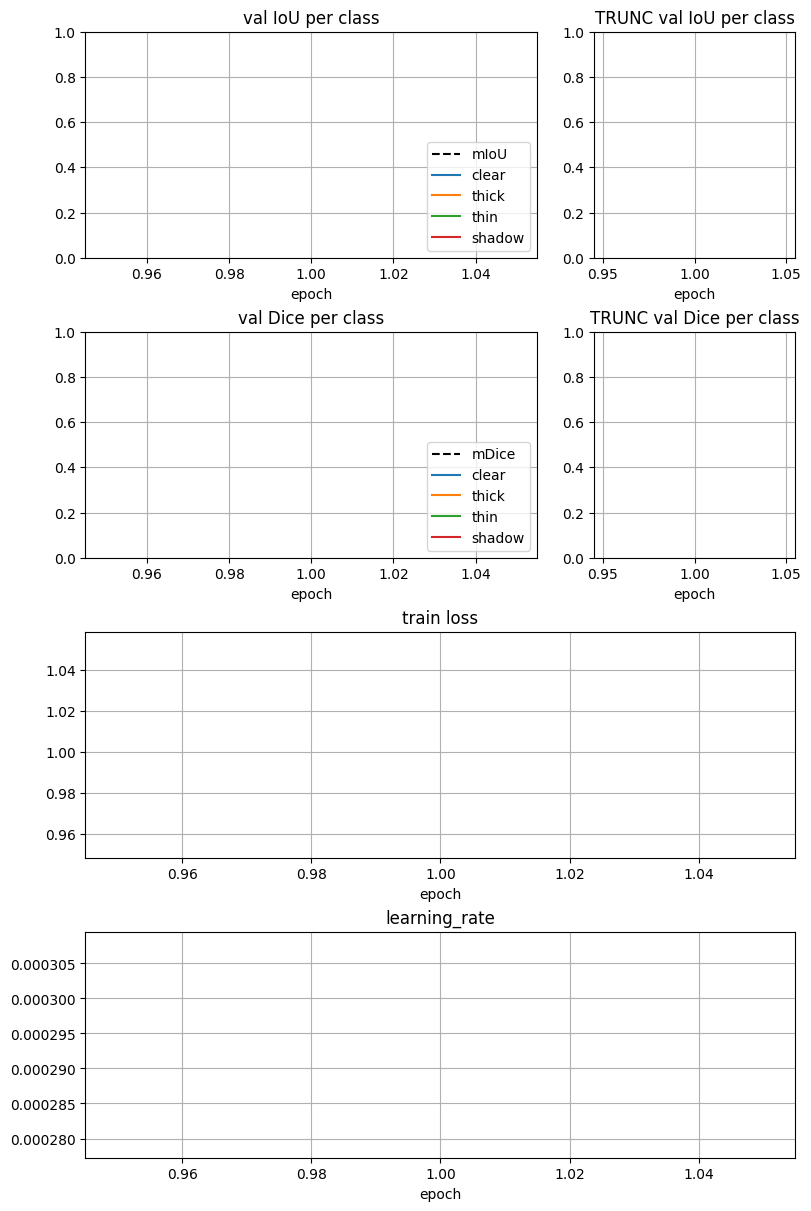

100%|██████████| 249/249 [05:39<00:00,  1.37s/it]


epoch 2: loss=0.801  mIoU=0.602  mDice=0.739
  clear   IoU=0.745  Dice=0.854
  thick   IoU=0.772  Dice=0.871
  thin    IoU=0.442  Dice=0.613
  shadow  IoU=0.448  Dice=0.619
lr: 0.00027421729424061787


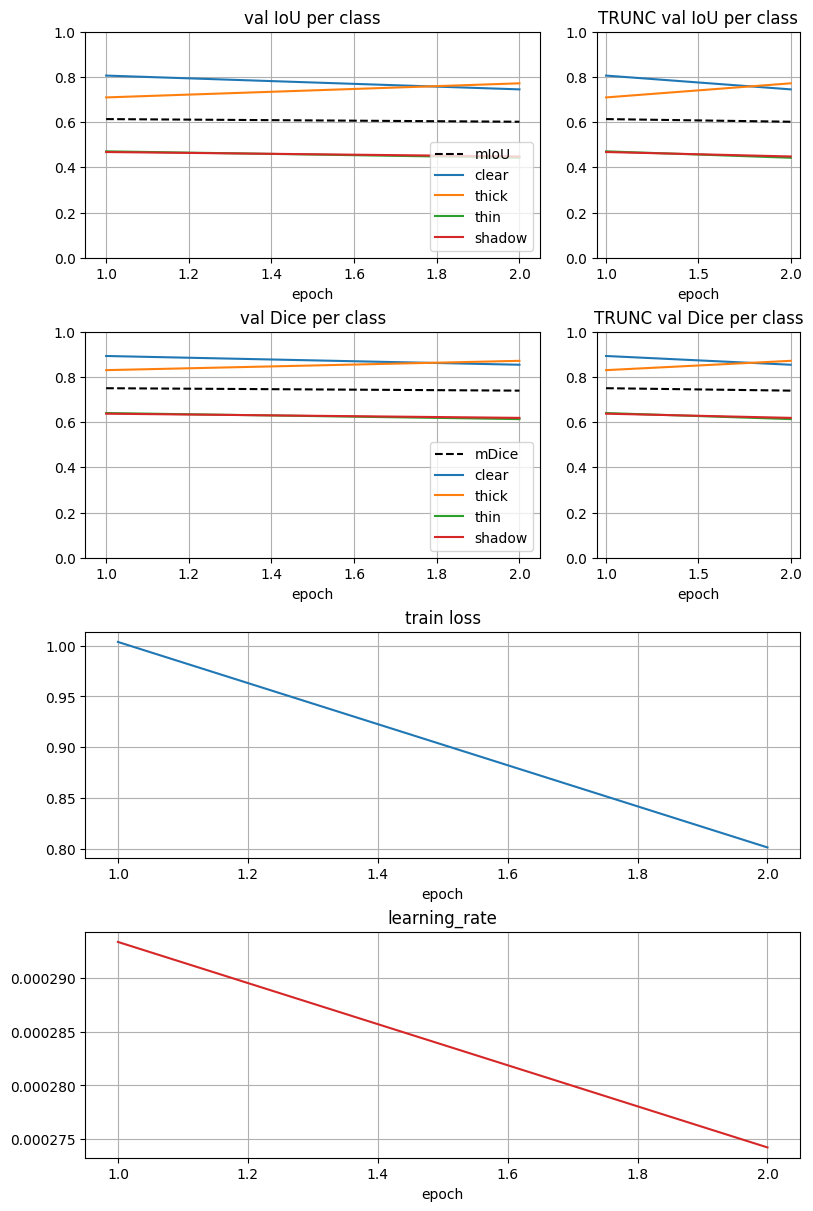

100%|██████████| 249/249 [05:34<00:00,  1.34s/it]


epoch 3: loss=0.730  mIoU=0.648  mDice=0.775
  clear   IoU=0.836  Dice=0.911
  thick   IoU=0.771  Dice=0.871
  thin    IoU=0.451  Dice=0.621
  shadow  IoU=0.533  Dice=0.695
lr: 0.00024435100905948387


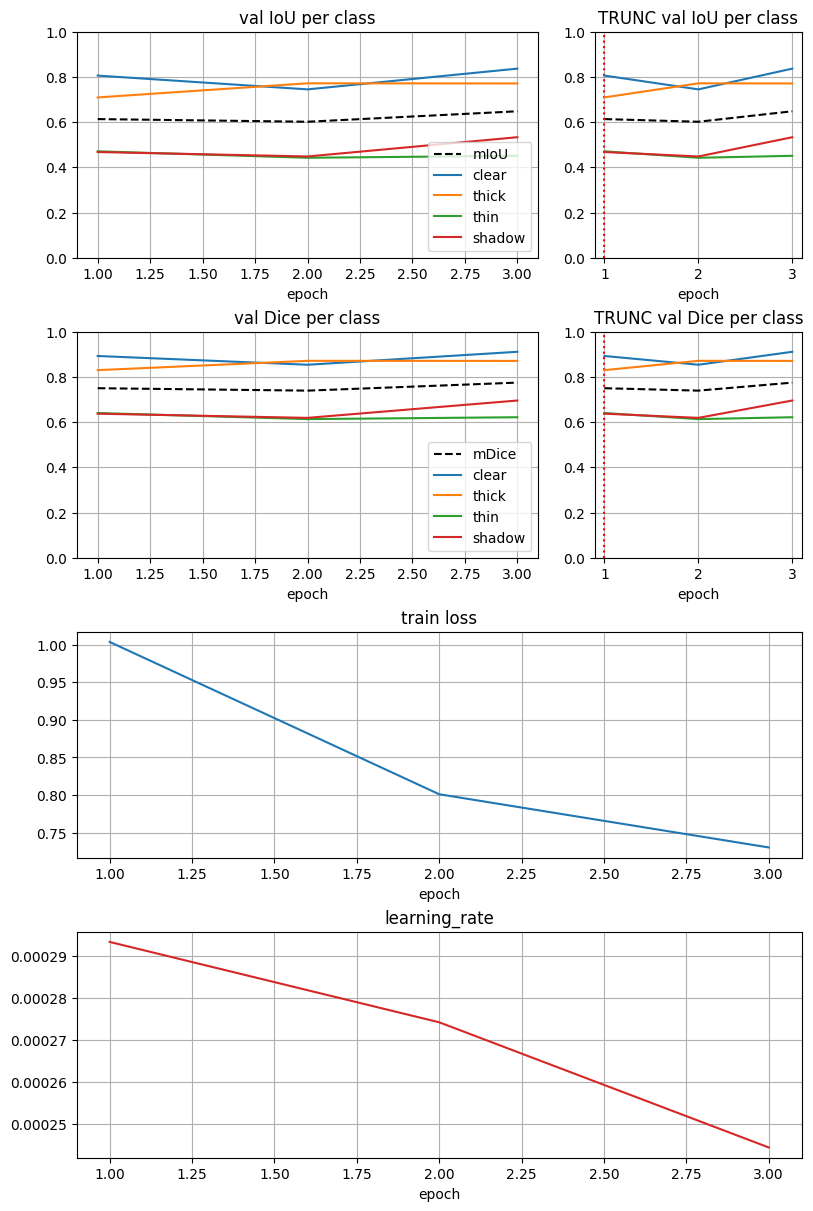

100%|██████████| 249/249 [05:29<00:00,  1.32s/it]


epoch 4: loss=0.674  mIoU=0.662  mDice=0.787
  clear   IoU=0.821  Dice=0.902
  thick   IoU=0.797  Dice=0.887
  thin    IoU=0.534  Dice=0.697
  shadow  IoU=0.495  Dice=0.663
lr: 0.00020671729424061788


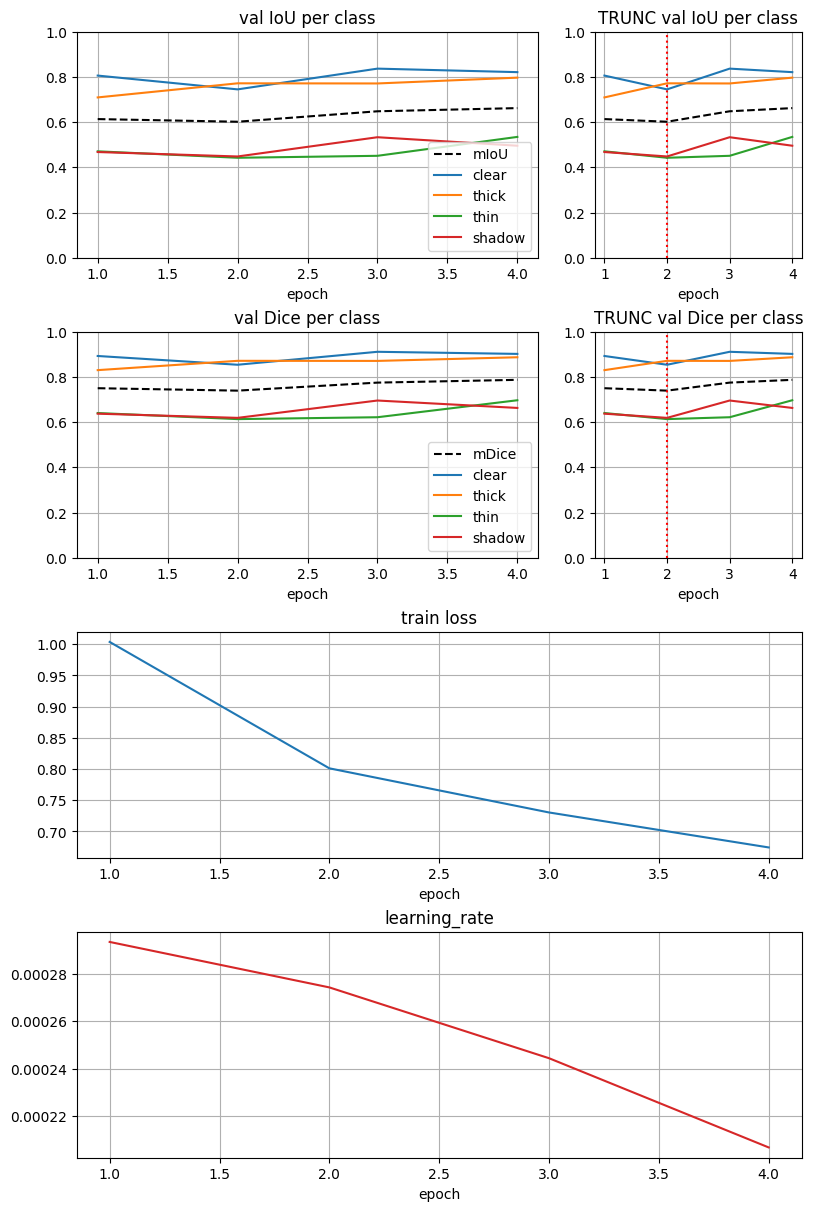

100%|██████████| 249/249 [05:27<00:00,  1.32s/it]


epoch 5: loss=0.641  mIoU=0.634  mDice=0.765
  clear   IoU=0.774  Dice=0.872
  thick   IoU=0.779  Dice=0.876
  thin    IoU=0.437  Dice=0.608
  shadow  IoU=0.545  Dice=0.705
lr: 0.00016499999999999997


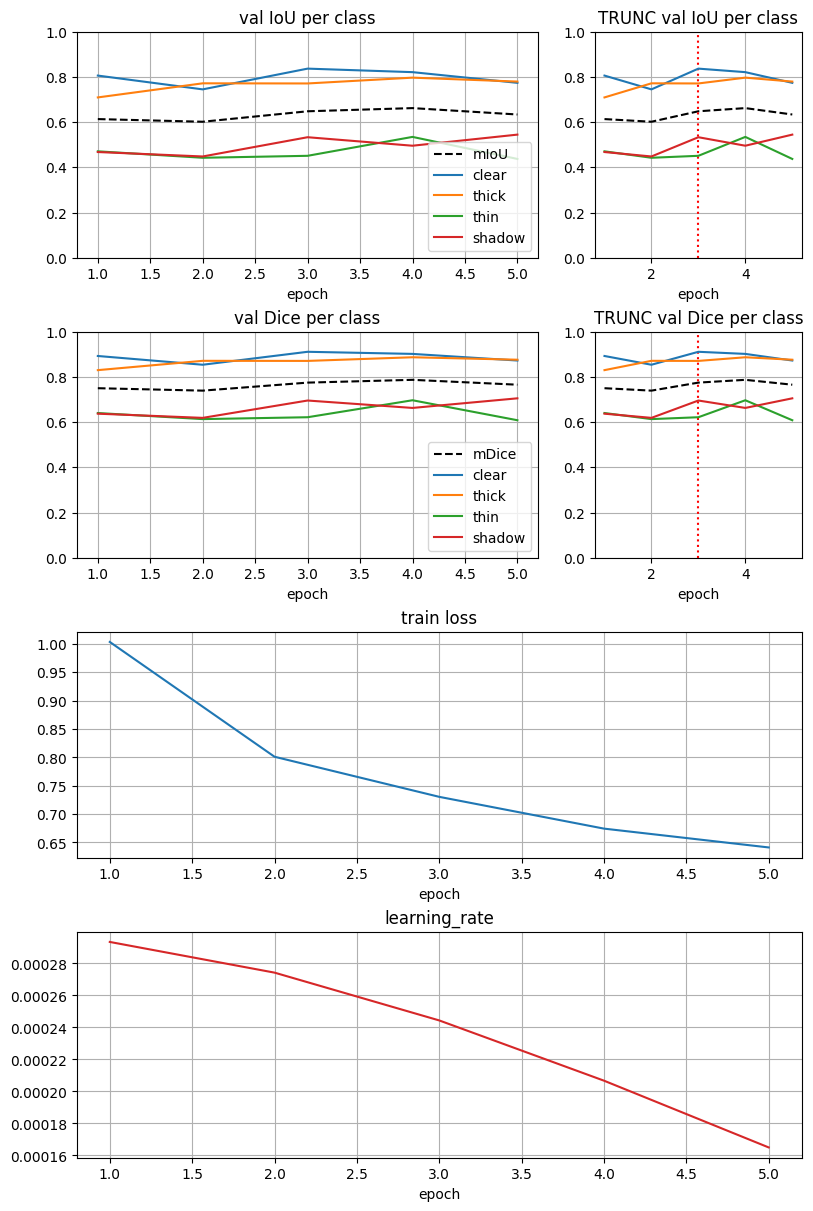

100%|██████████| 249/249 [05:41<00:00,  1.37s/it]


epoch 6: loss=0.621  mIoU=0.687  mDice=0.807
  clear   IoU=0.842  Dice=0.914
  thick   IoU=0.807  Dice=0.893
  thin    IoU=0.536  Dice=0.698
  shadow  IoU=0.564  Dice=0.721
lr: 0.0001232827057593821


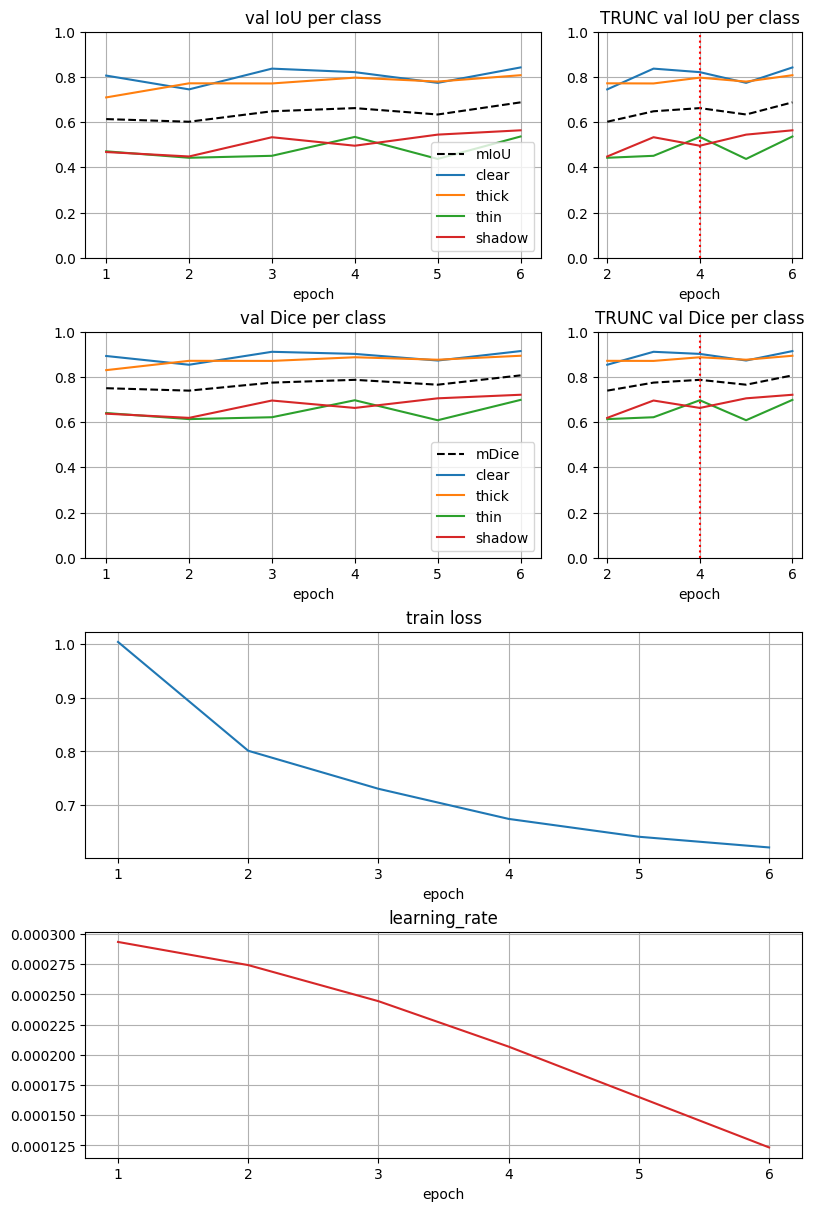

100%|██████████| 249/249 [05:30<00:00,  1.33s/it]


epoch 7: loss=0.583  mIoU=0.687  mDice=0.806
  clear   IoU=0.855  Dice=0.922
  thick   IoU=0.793  Dice=0.885
  thin    IoU=0.545  Dice=0.705
  shadow  IoU=0.554  Dice=0.713
lr: 8.564899094051613e-05


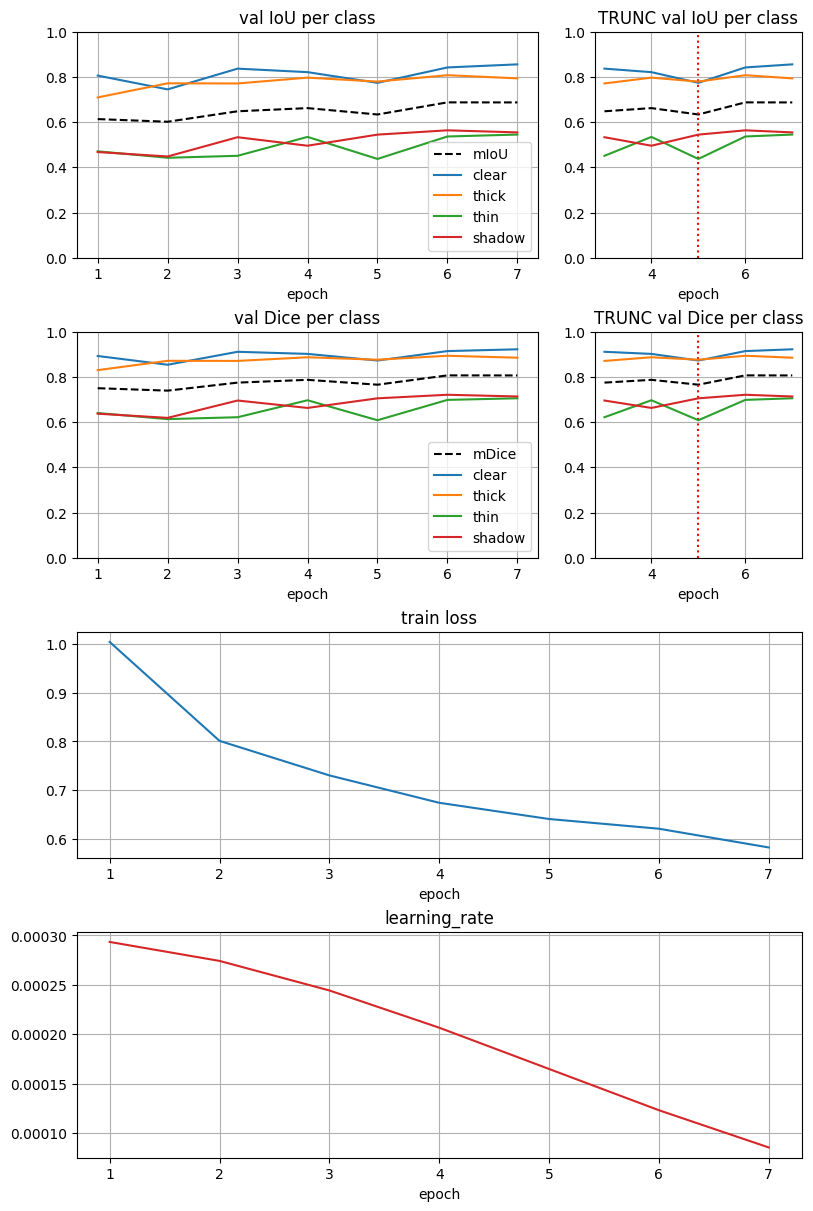

100%|██████████| 249/249 [05:28<00:00,  1.32s/it]


epoch 8: loss=0.560  mIoU=0.709  mDice=0.823
  clear   IoU=0.858  Dice=0.924
  thick   IoU=0.819  Dice=0.901
  thin    IoU=0.570  Dice=0.726
  shadow  IoU=0.590  Dice=0.742
lr: 5.5782705759382104e-05


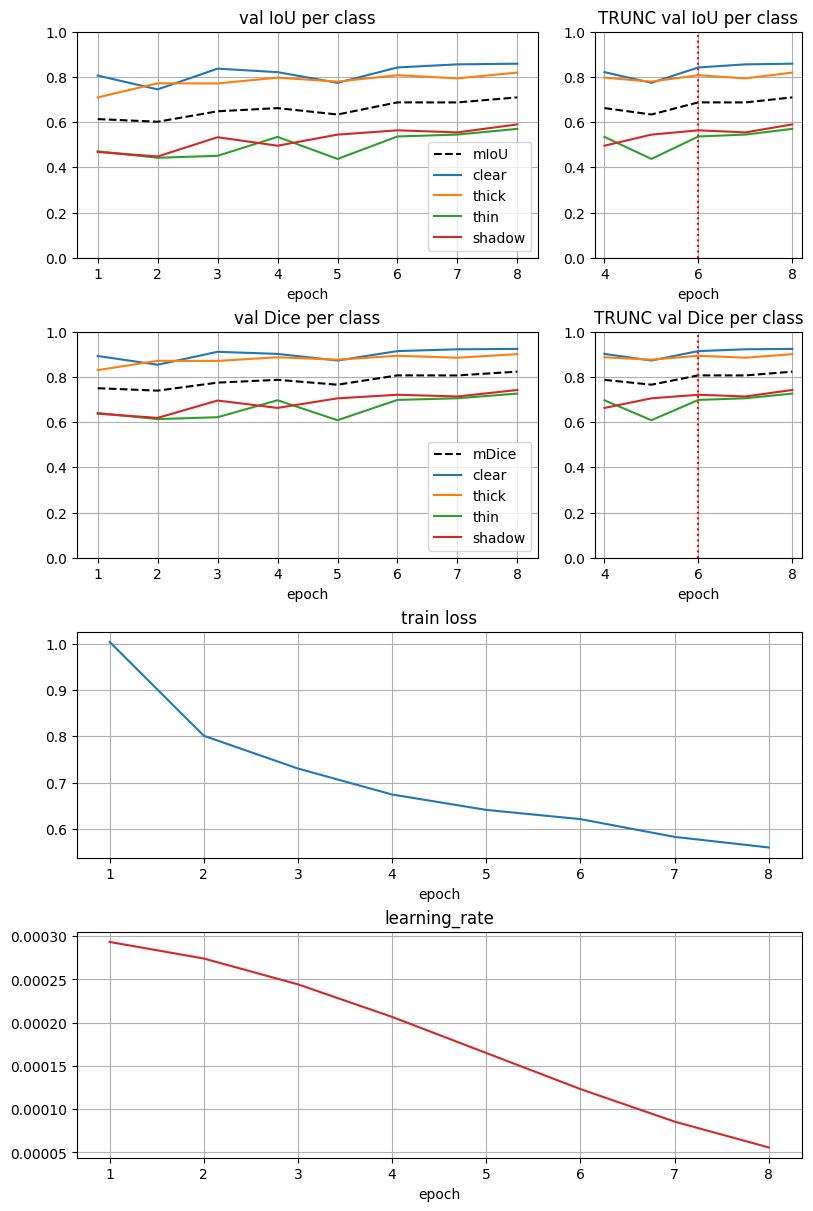

100%|██████████| 249/249 [05:34<00:00,  1.34s/it]


epoch 9: loss=0.546  mIoU=0.711  mDice=0.824
  clear   IoU=0.859  Dice=0.924
  thick   IoU=0.822  Dice=0.903
  thin    IoU=0.577  Dice=0.732
  shadow  IoU=0.587  Dice=0.740
lr: 3.660737030015427e-05


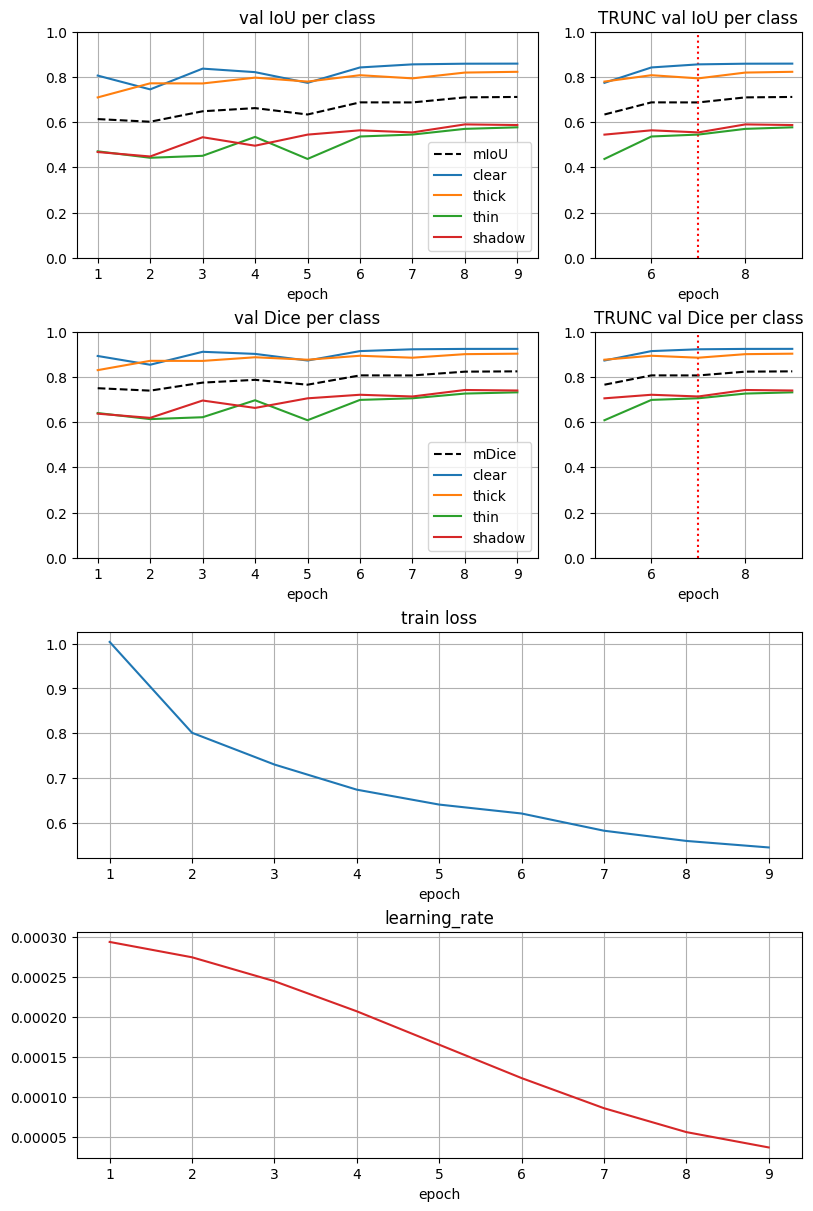

100%|██████████| 249/249 [05:32<00:00,  1.33s/it]


epoch 10: loss=0.524  mIoU=0.719  mDice=0.830
  clear   IoU=0.864  Dice=0.927
  thick   IoU=0.827  Dice=0.905
  thin    IoU=0.586  Dice=0.739
  shadow  IoU=0.600  Dice=0.750
lr: 0.00015


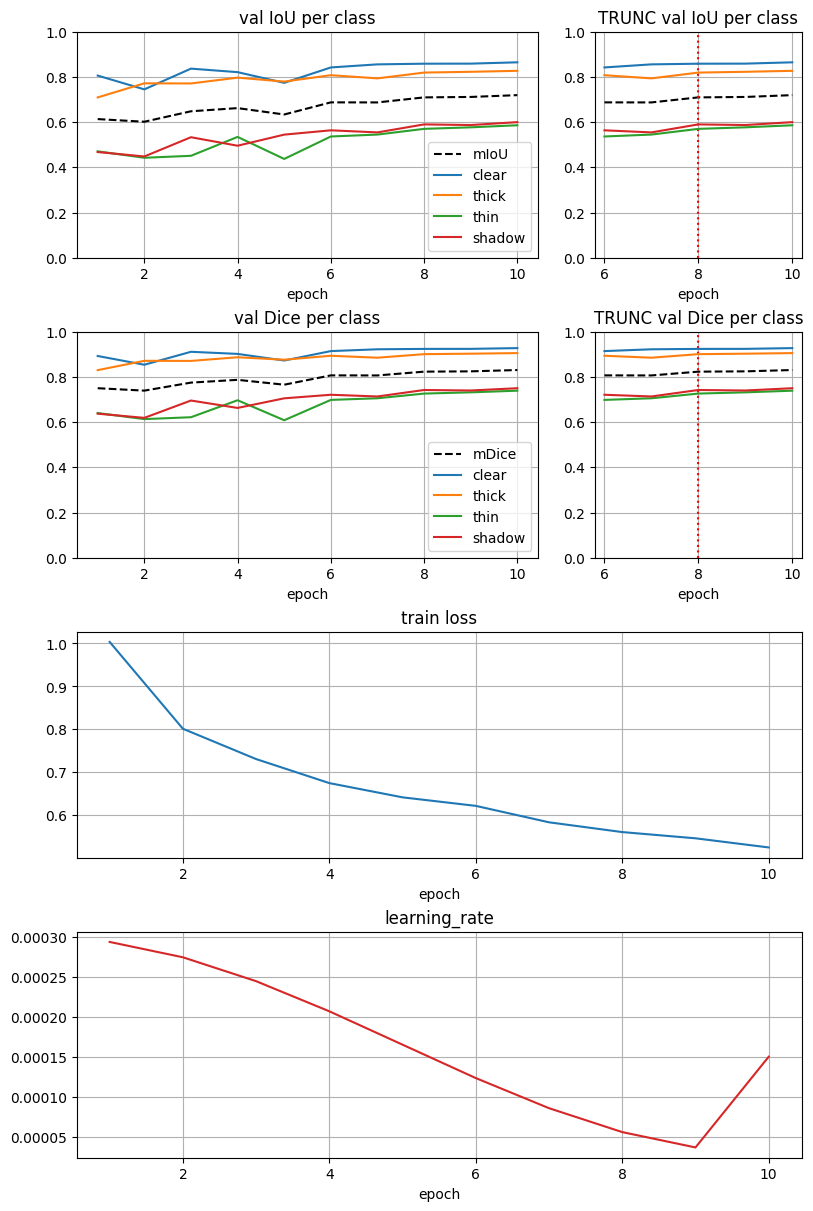

100%|██████████| 249/249 [05:21<00:00,  1.29s/it]


epoch 11: loss=0.575  mIoU=0.704  mDice=0.819
  clear   IoU=0.856  Dice=0.922
  thick   IoU=0.823  Dice=0.903
  thin    IoU=0.545  Dice=0.705
  shadow  IoU=0.594  Dice=0.745
lr: 0.00014669631484992286


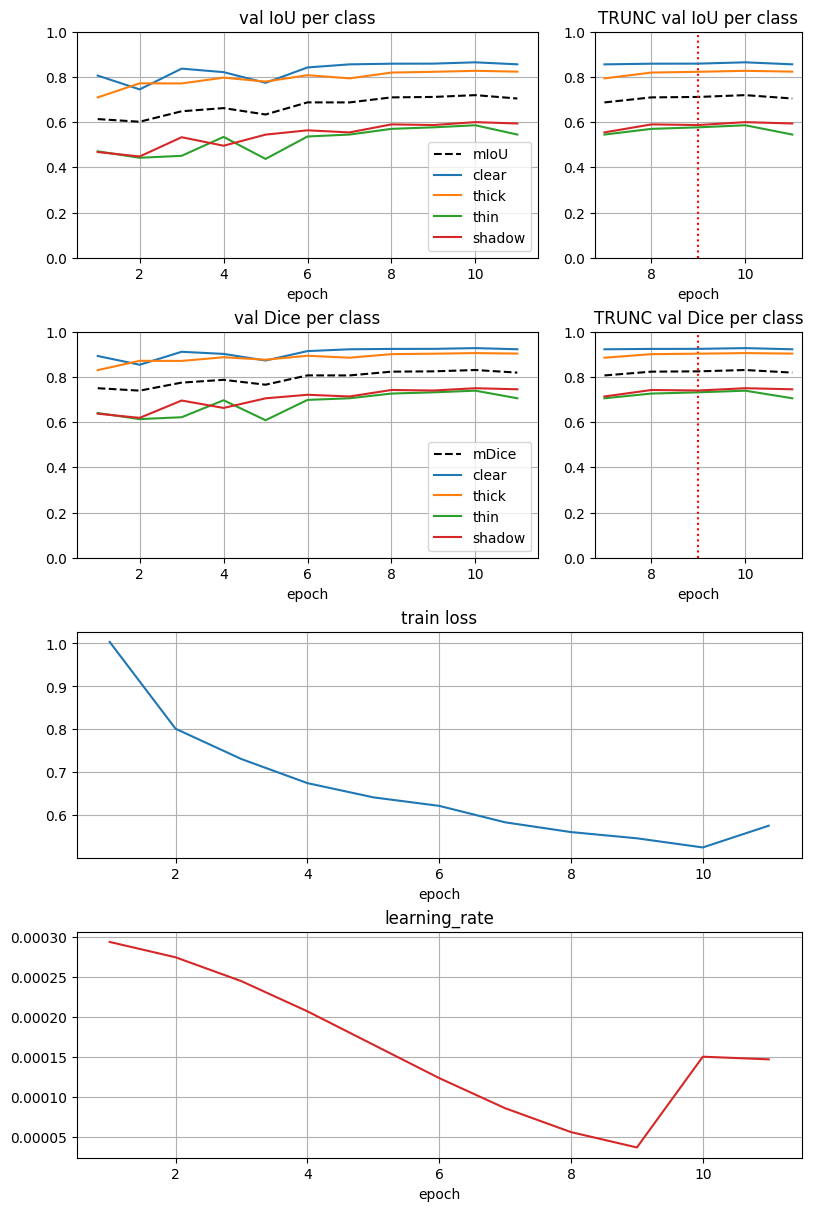

100%|██████████| 249/249 [05:29<00:00,  1.33s/it]


epoch 12: loss=0.565  mIoU=0.695  mDice=0.812
  clear   IoU=0.842  Dice=0.914
  thick   IoU=0.822  Dice=0.902
  thin    IoU=0.555  Dice=0.714
  shadow  IoU=0.561  Dice=0.719
lr: 0.00013710864712030893


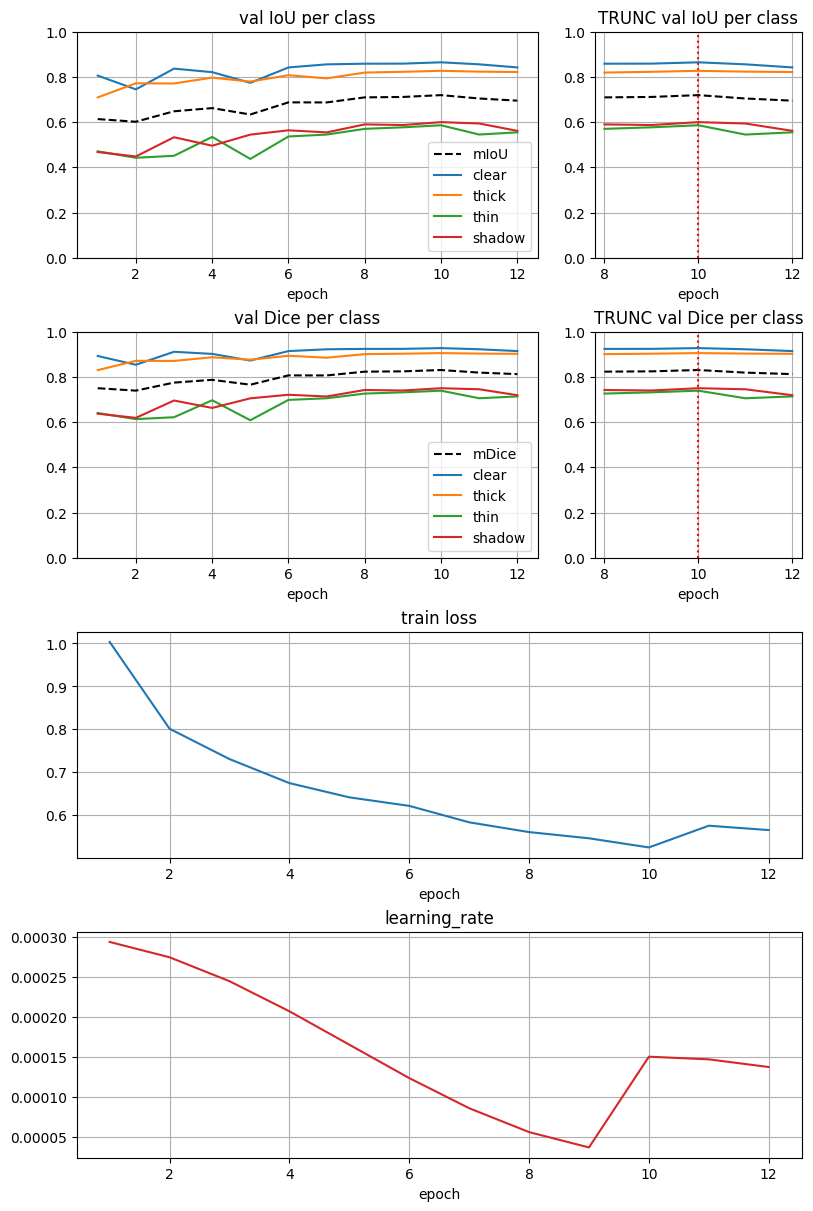

100%|██████████| 249/249 [05:28<00:00,  1.32s/it]


epoch 13: loss=0.556  mIoU=0.712  mDice=0.824
  clear   IoU=0.862  Dice=0.926
  thick   IoU=0.825  Dice=0.904
  thin    IoU=0.554  Dice=0.713
  shadow  IoU=0.606  Dice=0.754
lr: 0.00012217550452974193


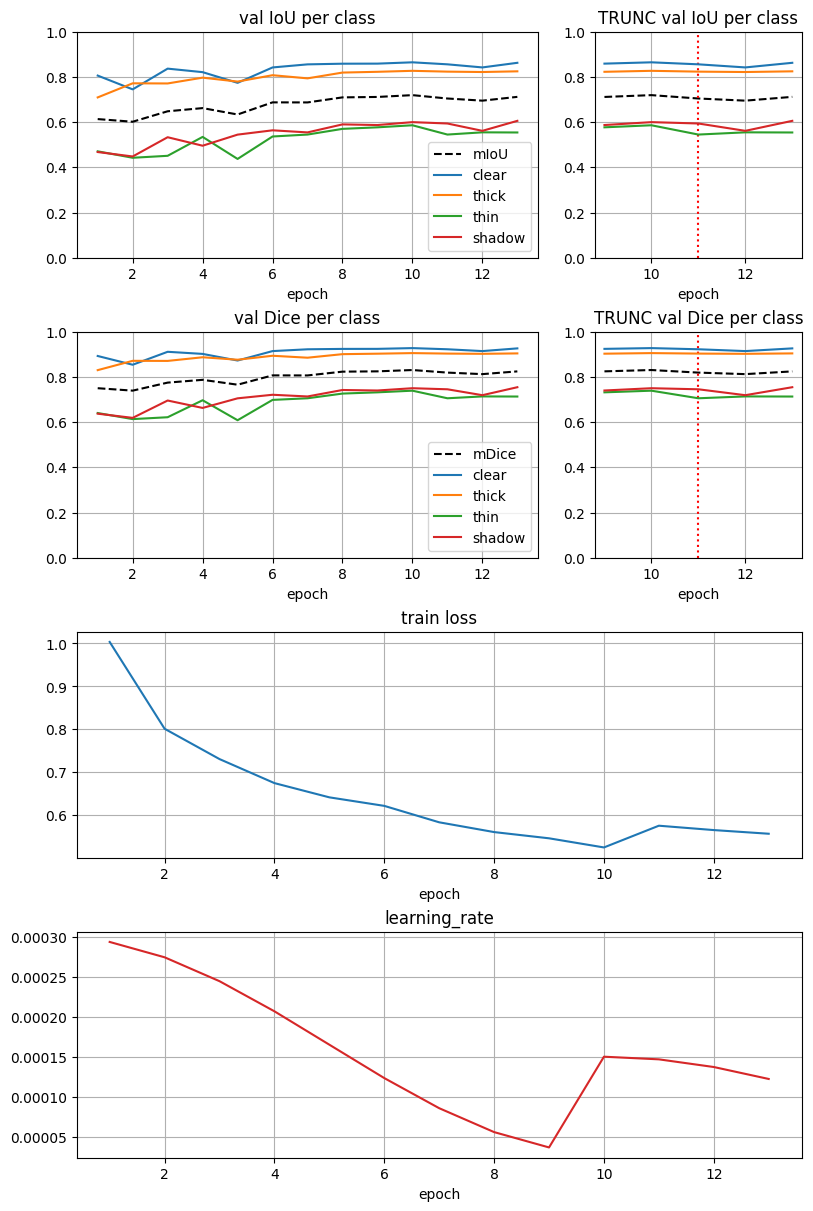

100%|██████████| 249/249 [05:52<00:00,  1.42s/it]


epoch 14: loss=0.541  mIoU=0.708  mDice=0.822
  clear   IoU=0.860  Dice=0.925
  thick   IoU=0.818  Dice=0.900
  thin    IoU=0.565  Dice=0.722
  shadow  IoU=0.586  Dice=0.739
lr: 0.00010335864712030894


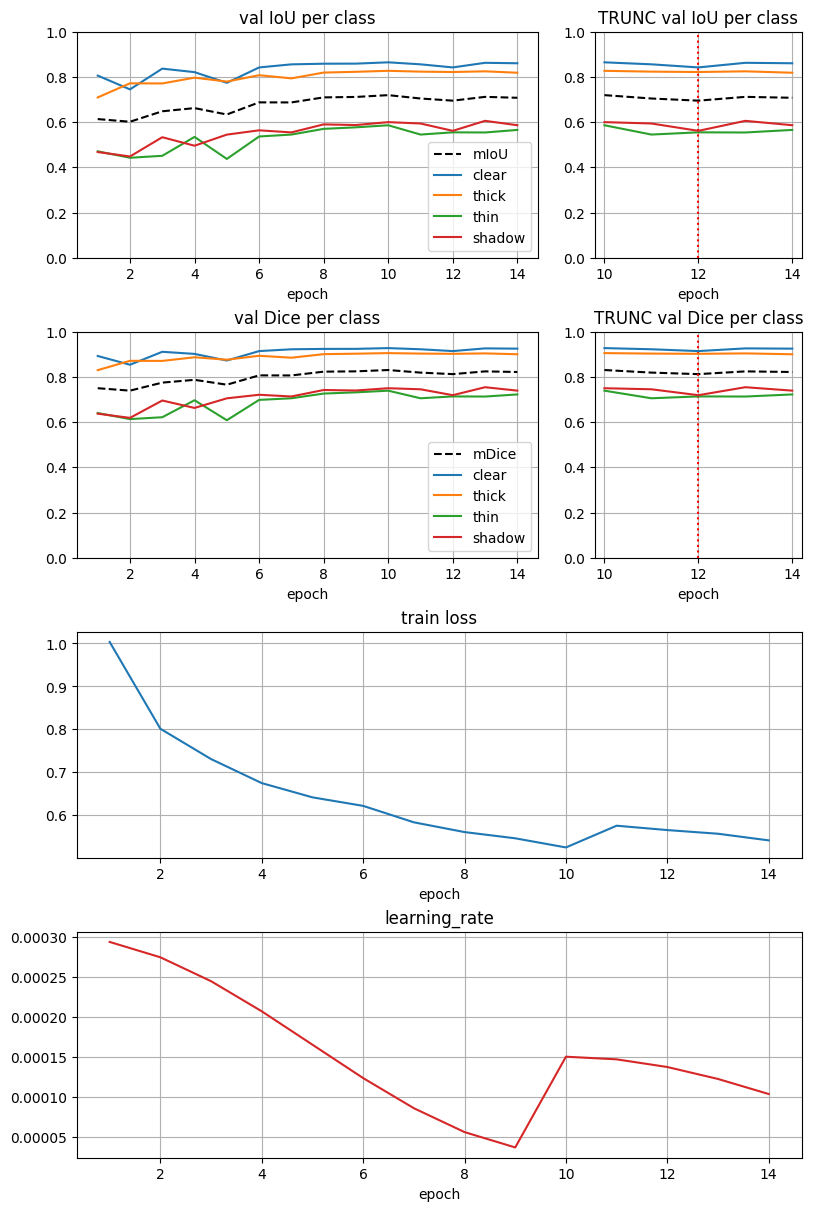

100%|██████████| 249/249 [05:55<00:00,  1.43s/it]


epoch 15: loss=0.529  mIoU=0.700  mDice=0.816
  clear   IoU=0.849  Dice=0.919
  thick   IoU=0.824  Dice=0.903
  thin    IoU=0.572  Dice=0.728
  shadow  IoU=0.555  Dice=0.714
lr: 8.249999999999999e-05


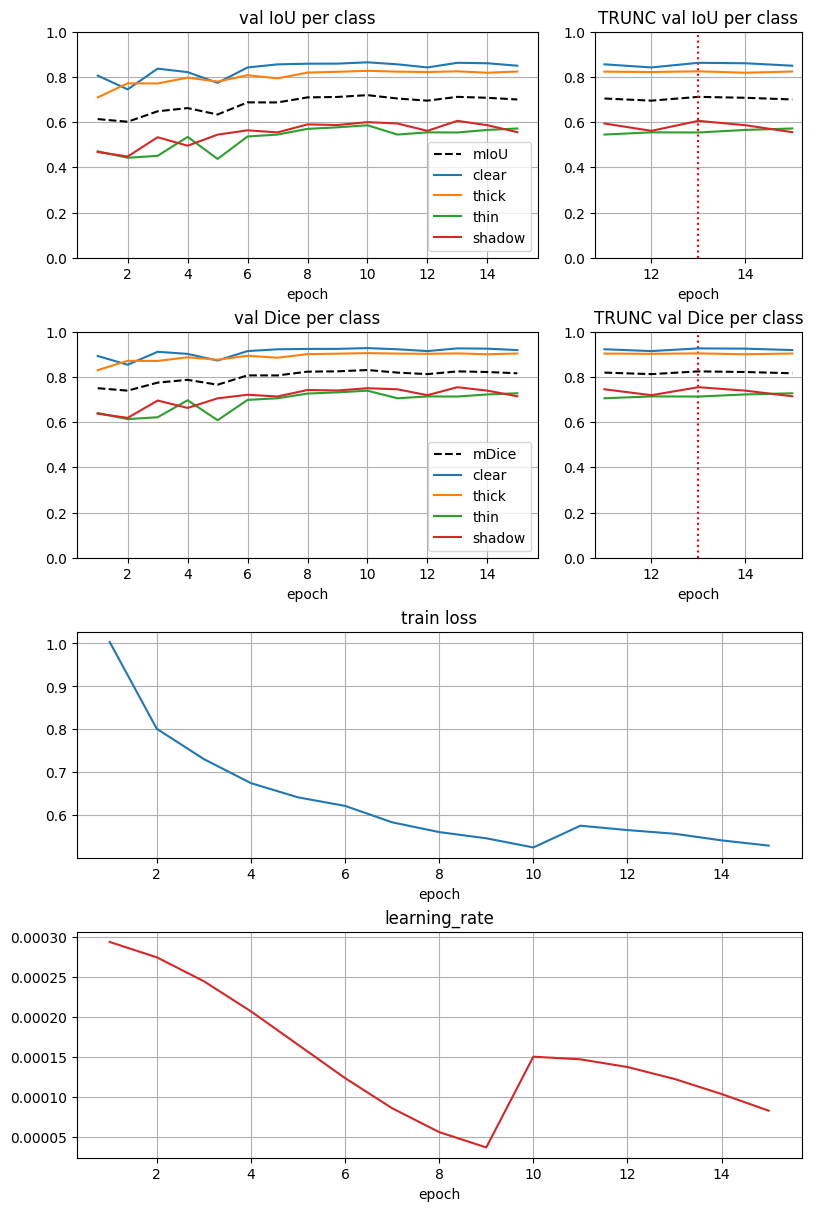

100%|██████████| 249/249 [06:15<00:00,  1.51s/it]


epoch 16: loss=0.518  mIoU=0.717  mDice=0.829
  clear   IoU=0.870  Dice=0.930
  thick   IoU=0.824  Dice=0.903
  thin    IoU=0.593  Dice=0.744
  shadow  IoU=0.584  Dice=0.737
lr: 6.164135287969105e-05


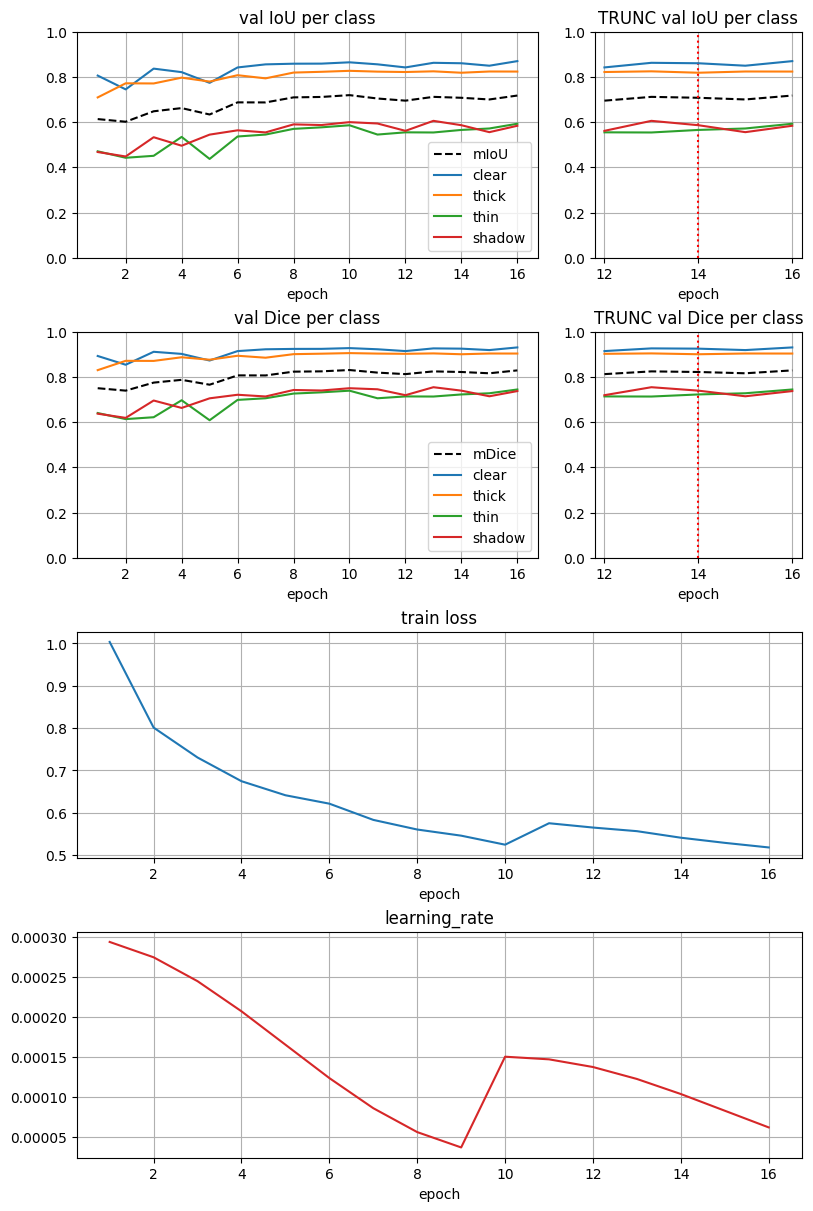

100%|██████████| 249/249 [06:25<00:00,  1.55s/it]


epoch 17: loss=0.512  mIoU=0.725  mDice=0.834
  clear   IoU=0.873  Dice=0.932
  thick   IoU=0.825  Dice=0.904
  thin    IoU=0.582  Dice=0.736
  shadow  IoU=0.618  Dice=0.764
lr: 4.2824495470258065e-05


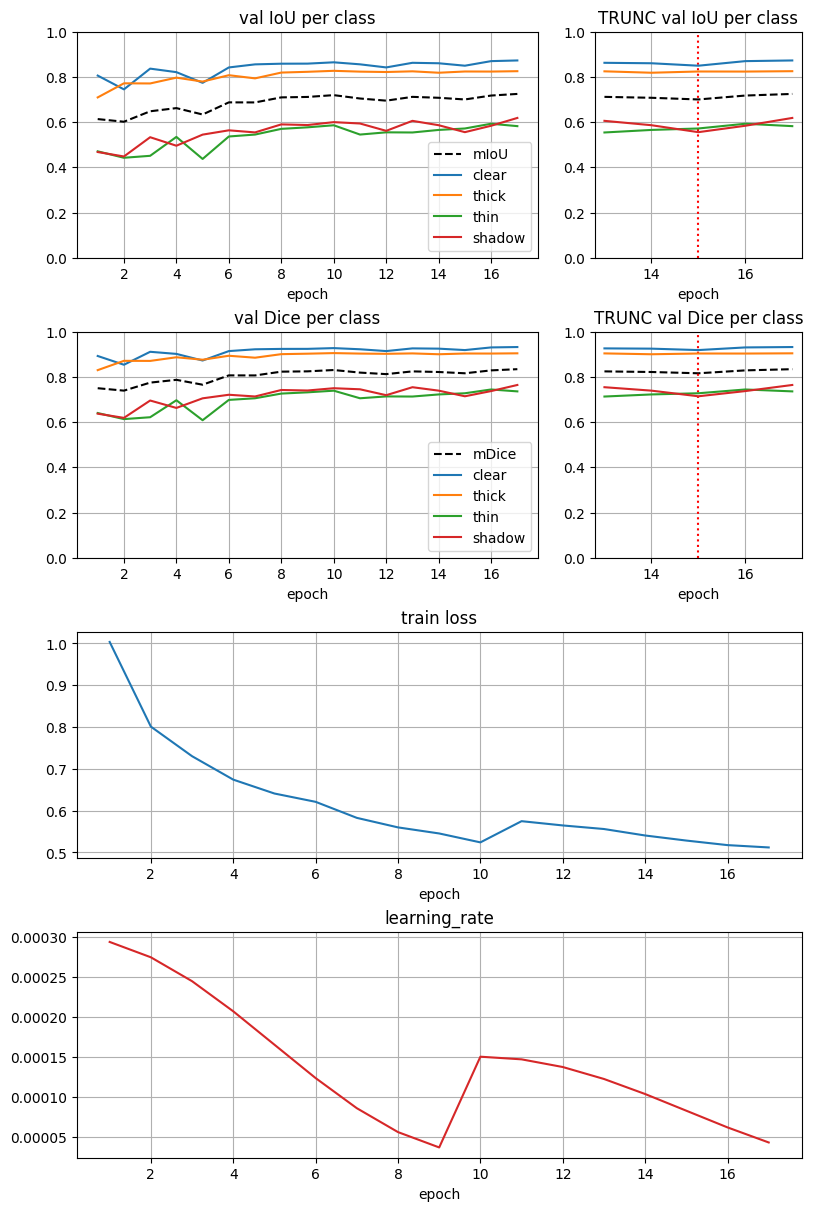

100%|██████████| 249/249 [05:54<00:00,  1.43s/it]


epoch 18: loss=0.488  mIoU=0.719  mDice=0.830
  clear   IoU=0.869  Dice=0.930
  thick   IoU=0.821  Dice=0.902
  thin    IoU=0.583  Dice=0.736
  shadow  IoU=0.601  Dice=0.751
lr: 2.7891352879691052e-05


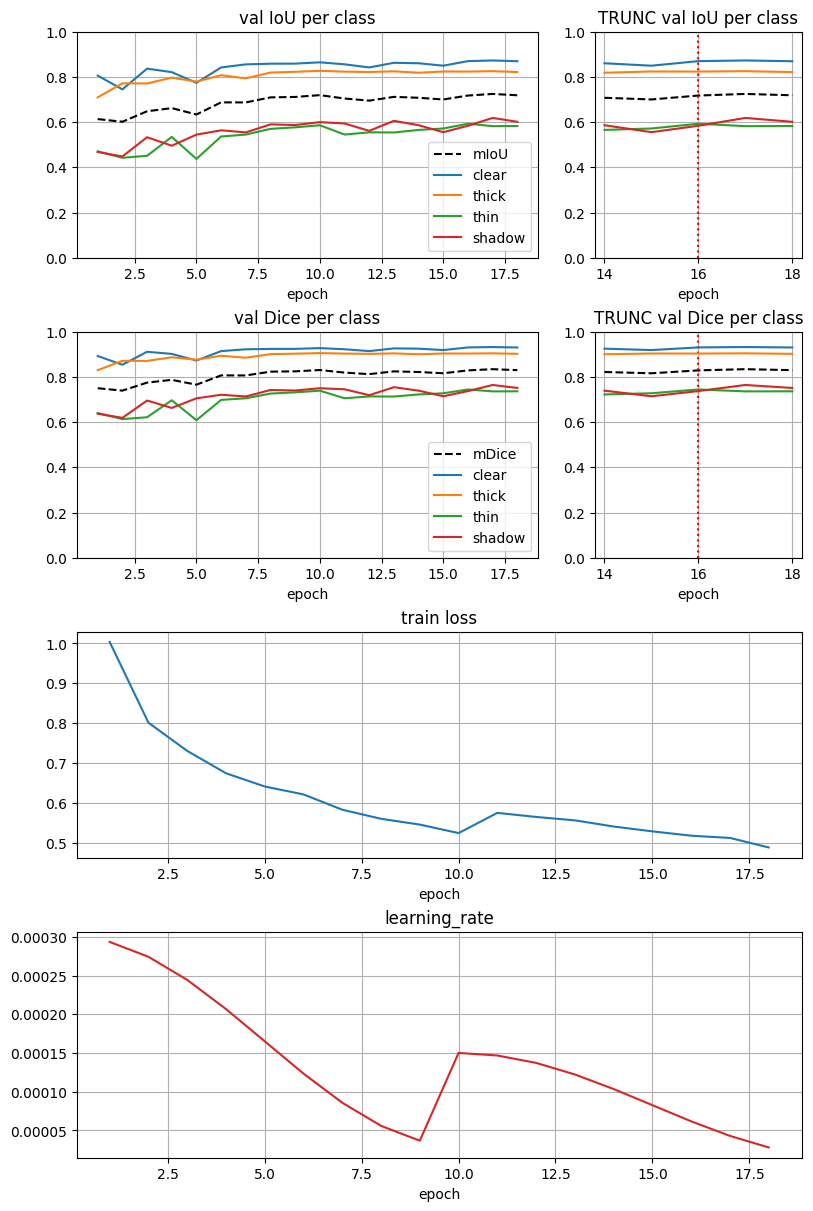

100%|██████████| 249/249 [05:51<00:00,  1.41s/it]


epoch 19: loss=0.469  mIoU=0.720  mDice=0.831
  clear   IoU=0.868  Dice=0.929
  thick   IoU=0.826  Dice=0.905
  thin    IoU=0.568  Dice=0.725
  shadow  IoU=0.619  Dice=0.765
lr: 1.8303685150077136e-05


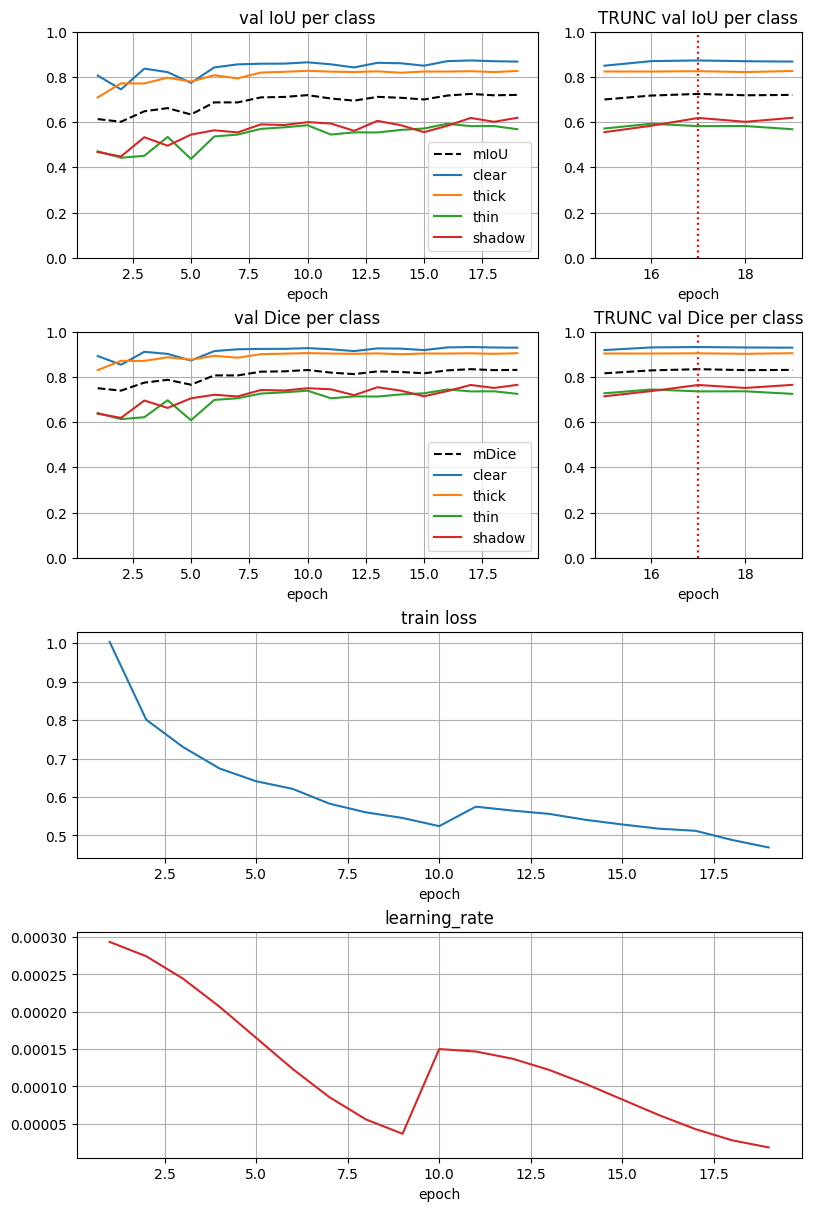

100%|██████████| 249/249 [06:15<00:00,  1.51s/it]


epoch 20: loss=0.462  mIoU=0.724  mDice=0.833
  clear   IoU=0.869  Dice=0.930
  thick   IoU=0.830  Dice=0.907
  thin    IoU=0.590  Dice=0.742
  shadow  IoU=0.606  Dice=0.754
lr: 7.5e-05


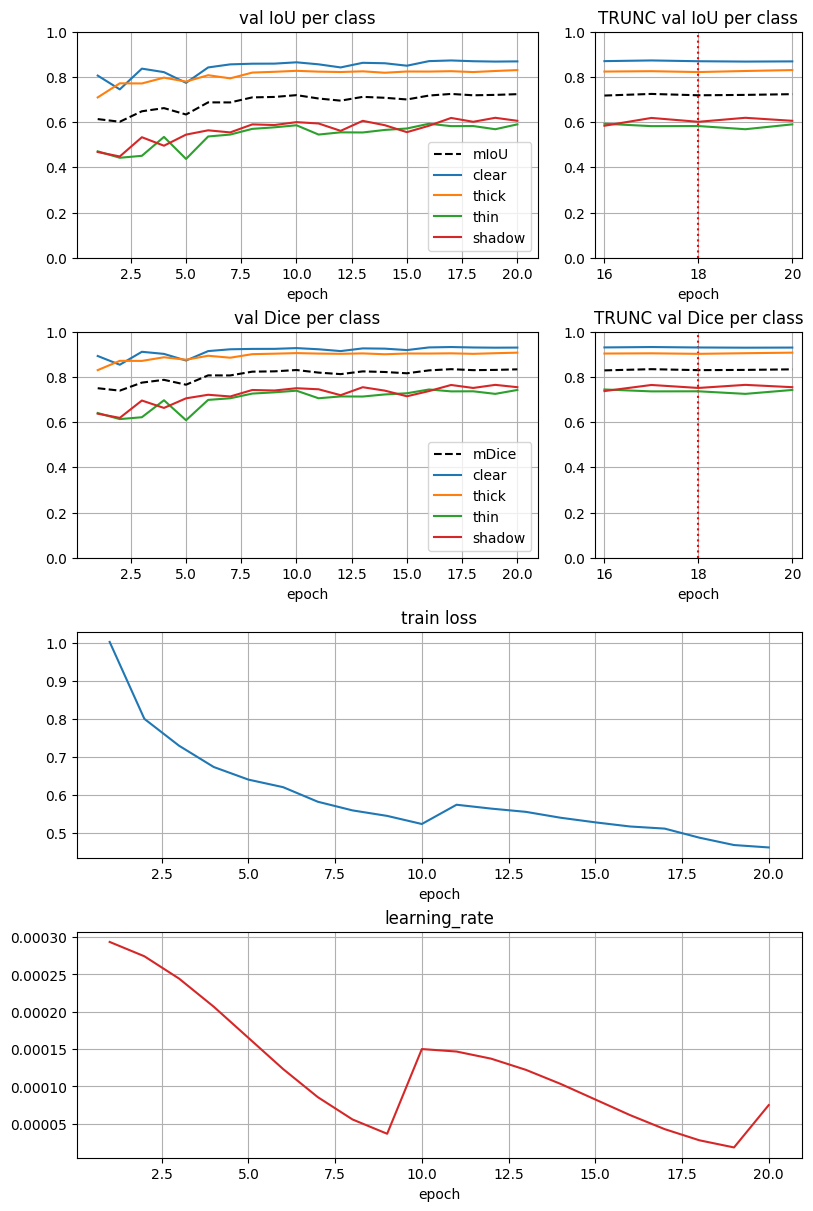

In [10]:
notebook_launcher(train_fn, num_processes=2)

In [11]:
def compute_class_weights(data_dir, num_classes=4):
    meta = pd.read_csv(os.path.join(data_dir, "metadata.csv"))
    train = meta[meta["split"] == "train"]
    
    counts = np.zeros(num_classes, dtype=np.int64)
    for _, row in tqdm.tqdm(train.iterrows(), total=len(train)):
        with rio.open(os.path.join(data_dir, row["label"])) as src:
            mask = src.read(1)
        for c in range(num_classes):
            counts[c] += (mask == c).sum()
    
    # median frequency balancing
    freq = counts / counts.sum()
    median_freq = np.median(freq)
    weights = median_freq / freq
    weights = weights / weights.sum() * num_classes  # нормализация
    return torch.tensor(weights, dtype=torch.float32)

w = compute_class_weights(DATA)
print(dict(zip(CLASS_NAMES, w.tolist())))

100%|██████████| 7951/7951 [01:15<00:00, 104.96it/s]


{'clear': 0.2692376375198364, 'thick': 0.5410593748092651, 'thin': 1.556660771369934, 'shadow': 1.6330422163009644}


In [12]:
model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=7,
    classes=4,
)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = CosineAnnealingWarmRestartsDecay(
    optimizer,
    T_0=10,
    T_mult=1,
    eta_min=3e-5,   # минимум первого цикла
    decay=0.5,      # каждый цикл весь диапазон сжимается в 3 раза
)


In [13]:
temp = []
temp.append(optimizer.param_groups[0]['lr'])
for i in range(100):
    scheduler.step()
    temp.append(optimizer.param_groups[0]['lr'])

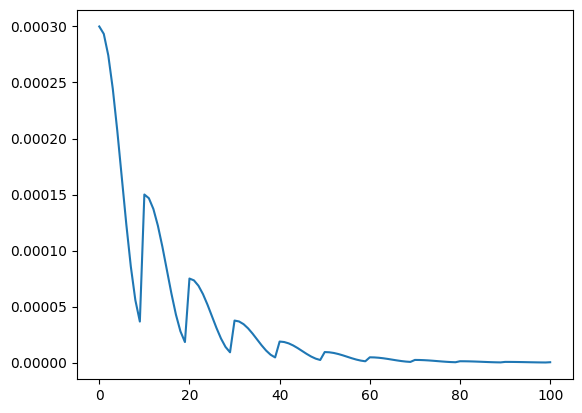

In [14]:
plt.plot(temp)